[![Open In Colab](https://raw.githubusercontent.com/crunchdao/competitions/refs/heads/master/documentation/badge/open-in-colab.svg)](https://colab.research.google.com/github/crunchdao/crunch-synth/blob/master/crunch_synth/examples/lightgbmtracker.ipynb)

![Banner](https://raw.githubusercontent.com/crunchdao/competitions/refs/heads/master/competitions/synth/assets/banner.webp)

# Synth Game

The goal is to anticipate how asset prices will evolve by providing not a single forecasted value, but a **full probability distribution over the future price change at multiple forecast horizons and steps.**

# Example Tracker: LightGBM Volatility Model

This notebook provides a **ML baseline tracker implementation** for the SYNTH challenge.

The workflow is:

1. Load historical asset price and exogenous data
2. Convert prices into returns
3. Extract statistical features from recent history
4. Train a LightGBM regression model to predict **future volatility**
5. Use the predicted volatility to generate a **probability distribution of future returns**
6. Run the tracker inside the evaluation framework

This notebook is intended as a **starting point**. You are encouraged to experiment with:

- Exogenous data
- Feature engineering
- Model parameters
- Forecast distribution assumptions
- Data preprocessing

The final predictions are evaluated using **CRPS** scoring.

## Setup

In [ ]:
# Install required dependencies
%pip install crunch_synth

In [ ]:
import numpy as np
import pandas as pd
import os
from tqdm.std import tqdm
from datetime import datetime, timezone, timedelta
import pickle
import warnings

## png render instead of plotly
# import plotly.io as pio
# pio.renderers.default = "png"  
# pio.renderers["png"].width = 1200
# pio.renderers["png"].height = 500

from crunch_synth import (
    TrackerBase,
    SubTracker,
    TrackerEvaluator,
    FORECAST_PROFILES,
    SUPPORTED_ASSETS,
    pricedb,
    PriceStore,
    Asset, 
    PriceData,
    load_test_prices_once,
    load_initial_price_histories_once,
    visualize_price_data,
    count_evaluations,
    plot_quarantine,
    plot_scores,
)

## Configurations

In [ ]:
##########
# For each asset and historical timestamp, generate density forecasts
# over a fixed forecast horizon (e.g. 24h or 1h) at multiple temporal
# resolutions and evaluate them against realized outcomes.

# Select which forecast profile to evaluate
ACTIVE_HORIZON = "24h"  # options: "24h", "1h"

# Assets to evaluate
if ACTIVE_HORIZON == "24h":
    assets = ["BTC", "SOL", "ETH", "XAUT", "SPYX", "NVDAX", "TSLAX", "AAPLX", "GOOGLX", "XRP", "HYPE", "WTIOIL"] # Supported assets: "BTC", "SOL", "ETH", "XAUT", "SPYX", "NVDAX", "TSLAX", "AAPLX", "GOOGLX", "XRP", "HYPE", "WTIOIL"
else:
    assets = ["BTC", "SOL", "ETH", "XAUT", "HYPE"]  # Supported assets: "BTC", "SOL", "ETH", "XAUT", "HYPE"

# Filter (for backtesting)
assets = ["BTC"]

print("Supported assets:", ", ".join(SUPPORTED_ASSETS))
print("Selected assets:", ", ".join(assets))

HORIZON = FORECAST_PROFILES[ACTIVE_HORIZON]["horizon"]
STEPS = FORECAST_PROFILES[ACTIVE_HORIZON]["steps"]
INTERVAL = FORECAST_PROFILES[ACTIVE_HORIZON]["interval"]

# Base directory where all evaluation results will be stored
base_dir_results = "results"
os.makedirs(base_dir_results, exist_ok=True)

# End timestamp for the test data
# evaluation_end: datetime = datetime.now(timezone.utc)
evaluation_end: datetime = datetime(2026, 3, 26, 00, 00, 00, tzinfo=timezone.utc)

# Number of days of test data to load
# Note: the last `horizon` seconds of the time series will not be scored
days_test = 7

# Number of days of historical data used as warm-up before evaluation.
# This history is used only to initialize the tracker and is not scored.
days_history = 50

Supported assets: BTC, ETH, XAUT, SOL, SPYX, NVDAX, TSLAX, AAPLX, GOOGLX
Selected assets: BTC


## Data

In [4]:
## Load the last N days of price data (test period)
test_asset_prices = load_test_prices_once(
    assets, evaluation_end, days=days_test
)
# test_asset_prices : dict : {asset -> [(timestamp, price), ...]} used for evaluation.

## Train period
## Provide the tracker with initial historical data (for the first tick):
## load prices from the last H days up to N days ago
initial_histories = load_initial_price_histories_once(
    assets, evaluation_end, days_history=days_history, days_offset=days_test
)
# initial_histories : dict : {asset -> [(timestamp, price), ...]} used as warm-up history.

# Example: manually retrieving price history for an asset
# prices = pricedb.get_price_history(
#         asset="BTC",
#         from_=datetime(2024, 1, 1),
#         to=datetime(2024, 1, 3),
#     )

Dataset:


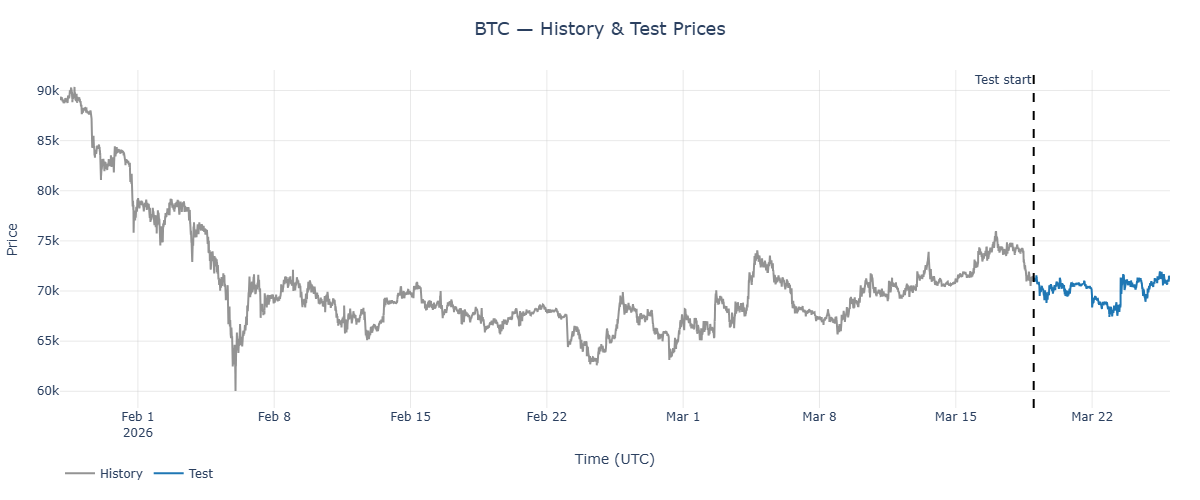

,asset,ts,price,split,time
0,BTC,1769558400,89133.887594,history,2026-01-28 00:00:00+00:00
1,BTC,1769558460,89098.957151,history,2026-01-28 00:01:00+00:00
2,BTC,1769558520,89082.211518,history,2026-01-28 00:02:00+00:00
3,BTC,1769558580,89043.770478,history,2026-01-28 00:03:00+00:00
4,BTC,1769558640,89062.440000,history,2026-01-28 00:04:00+00:00
...,...,...,...,...,...
82075,BTC,1774482900,71324.849108,test,2026-03-25 23:55:00+00:00
82076,BTC,1774482960,71351.058199,test,2026-03-25 23:56:00+00:00
82077,BTC,1774483020,71316.061819,test,2026-03-25 23:57:00+00:00
82078,BTC,1774483080,71305.203250,test,2026-03-25 23:58:00+00:00


In [5]:
visualize_price_data(
    history_data=initial_histories, test_data=test_asset_prices,
    selected_assets=None, show_graph=True
)

### Tracker Performance History

We retrieve the **live performance of trackers** from the challenge over the TEST time window:

⚠️ Note: Tracker performance data is only available starting from **2026-03-16**. If your evaluation period starts before this date, the pipeline will still run correctly, but you won't be able to compare your tracker with live competitors over that earlier period.

This dataset allows you to **compare your tracker against real competitors** and compute rankings based on actual challenge results.

In [6]:
from crunch_synth import load_and_prepare_trackers_history

df_trackers_history = load_and_prepare_trackers_history(HORIZON, assets, evaluation_end, days_test)
# If you don't want to use trackers history, set df_trackers_history to None
df_trackers_history

,tracker,horizon,asset,performed_at,resolvable_at,score
260253,13670,86400,BTC,2026-03-19 01:01:00+00:00,2026-03-20 01:01:00+00:00,15.791719
260254,13671,86400,BTC,2026-03-19 01:01:00+00:00,2026-03-20 01:01:00+00:00,15.833228
260255,13672,86400,BTC,2026-03-19 01:01:00+00:00,2026-03-20 01:01:00+00:00,15.786895
260256,13691,86400,BTC,2026-03-19 01:01:00+00:00,2026-03-20 01:01:00+00:00,15.847783
260257,13696,86400,BTC,2026-03-19 01:01:00+00:00,2026-03-20 01:01:00+00:00,17.956612
...,...,...,...,...,...,...
1158565,14015,86400,BTC,2026-03-25 23:44:00+00:00,2026-03-26 23:44:00+00:00,428.650543
1158566,13533,86400,BTC,2026-03-25 23:44:00+00:00,2026-03-26 23:44:00+00:00,428.650543
1158567,13552,86400,BTC,2026-03-25 23:44:00+00:00,2026-03-26 23:44:00+00:00,428.650543
1158568,14141,86400,BTC,2026-03-25 23:44:00+00:00,2026-03-26 23:44:00+00:00,13.660192


# Model training

In this section, the functions to train a model that predicts the **scale of future price movements** for each (horizon, asset).

Pipeline:

1. Convert price history into a time series dataframe
2. Extract statistical features from the recent window
3. Build a supervised dataset
4. Train a LightGBM model
5. Save the model for use inside the tracker

You can try new experiments with:
- feature engineering
- model type
- target definition

In [7]:
def compute_feat(past, timestamp, compute_time_feat=True):
    """
    Extract statistical features from a window of past returns.

    Features fall into three groups:

    1. Time context
    - hour of day
    - day of week

    2. Distribution statistics
    - mean, std, median, min, max
    - skewness and kurtosis

    3. Temporal / structural properties
    - linear trend (slope)
    - short-term and long-term volatility
    - lag-1 autocorrelation
    - energy and absolute variation

    Features are computed for the full lookback window.

    These features help the model detect patterns such as:
    - volatility clustering
    - intraday seasonal effects
    """

    def summary_features(x, is_constant, suffix=""):
        mean_ = np.mean(x)
        std_ = np.std(x)

        skew = ((x - mean_)**3).mean() / (std_**3 + 1e-9) if not is_constant else 0.0
        kurtosis = ((x - mean_)**4).mean() / (std_**4 + 1e-9) if not is_constant else 0.0

        values = [
            mean_,
            std_,
            np.median(x),
            np.min(x),
            np.max(x),
            skew,
            kurtosis,
            x[-1],
            x[0],
        ]

        names = [
            f"mean{suffix}",
            f"std{suffix}",
            f"median{suffix}",
            f"min{suffix}",
            f"max{suffix}",
            f"skew{suffix}",
            f"kurt{suffix}",
            f"last{suffix}",
            f"first{suffix}",
        ]

        return values, names

    def trend_features(x, is_constant, suffix=""):
        t = np.arange(len(x))
        slope = np.polyfit(t, x, 1)[0] if not is_constant else 0.0

        short_std = np.std(x[-25:])
        long_std = np.std(x[-100:])

        ac1 = np.corrcoef(x[:-1], x[1:])[0, 1] if len(x) > 1 and not is_constant else 0.0

        energy = np.sum(x**2)
        abs_sum = np.sum(np.abs(x))
        iqr = np.percentile(x, 90) - np.percentile(x, 10)

        values = [slope, short_std, long_std, ac1, energy, abs_sum, iqr]

        names = [
            f"slope{suffix}",
            f"short_std{suffix}",
            f"long_std{suffix}",
            f"ac1{suffix}",
            f"energy{suffix}",
            f"abs_sum{suffix}",
            f"iqr{suffix}",
        ]

        return values, names

    feats = []
    names = []

    # only constant values ?
    is_constant = np.allclose(past, past[0])

    # time features
    if compute_time_feat:
        feats += [
            timestamp.hour + timestamp.minute / 60,
            timestamp.weekday(),
        ]

        names += [
            "hour_of_day",
            "day_of_week",
        ]

    # full window
    v, n = summary_features(past, is_constant)
    feats += v
    names += n

    v, n = trend_features(past, is_constant)
    feats += v
    names += n

    return feats, names

In [8]:
def build_feature_dataframe(pairs_prices, dict_pairs_exogenous_series=None, resolution=300):
    """
    Build a dataframe with aligned prices for the main asset
    and all exogenous data stream.

    pairs -> (timestamp, value)
    """

    df = pd.DataFrame(pairs_prices, columns=["timestamp", "price"])
    df["timestamp"] = pd.to_datetime(df["timestamp"], unit="s")

    resolution_minute = int(resolution // 60)

    df = (
        df.resample(f"{resolution_minute}min", on="timestamp")
        .first()
        .reset_index()
        .sort_values("timestamp")
    )

    # merge each exogenous data stream using nearest backward direction
    if dict_pairs_exogenous_series is not None:
        for series_name, pairs_exogenous in dict_pairs_exogenous_series.items():

            df_exogenous = pd.DataFrame(
                pairs_exogenous, columns=["timestamp", f"value_{series_name}"]
            )

            df_exogenous["timestamp"] = pd.to_datetime(df_exogenous["timestamp"], unit="s")
            df_exogenous = df_exogenous.sort_values("timestamp")

            df = pd.merge_asof(
                df,
                df_exogenous,
                on="timestamp",
                direction="backward"
            )

    df = df.dropna()

    if len(df) == 0:
        raise ValueError("Empty dataset after alignment")

    return df


def build_training_data(pairs_prices, dict_pairs_exogenous_series=None, resolution=300, window_size=288, horizon_size=288):
    """
    Build supervised training dataset.

    pairs_prices: contains pairs of (timestamp, price)
    dict_pairs_exogenous_series: dict {asset:contains pairs of (timestamp, price)}
    resolution  : desired price sampling interval in seconds.
    window_size : number of past observations used as input
    horizon_size: number of future observations used for target

    For each timestamp t:

    Input features:
        statistical features computed from the previous `window_size` returns

    Target:
        the volatility (standard deviation) of returns over the next `horizon_size` steps

    Returns:
        X : feature matrix
        y : target volatility values
        feature_names : list of feature column names
    """

    df = build_feature_dataframe(pairs_prices, dict_pairs_exogenous_series, resolution)

    prices = df["price"].values
    timestamps = df["timestamp"].values

    returns = np.diff(prices)

    exogenous_returns = {
        col: np.diff(df[col].values)
        for col in df.columns if col.startswith("value_")
    }

    X = []
    y = []

    # Generate features and targets for each eligible timestamp
    for t in range(window_size, len(df) - horizon_size):

        feats, feature_names = compute_feat(
            returns[t-window_size:t],
            pd.Timestamp(timestamps[t])
        )

        # add exogenous features
        for col, r in exogenous_returns.items():

            feats_exogenous, feature_names_exogenous = compute_feat(
                r[t-window_size:t],
                pd.Timestamp(timestamps[t]),
                compute_time_feat=False
            )

            feats = np.concatenate([feats, feats_exogenous])
            feature_names = feature_names + [
                f"{col}_{n}" for n in feature_names_exogenous
            ]

        # Compute target volatility over future returns
        future_returns = returns[t:t+horizon_size]
        target = np.std(future_returns)

        X.append(feats)
        y.append(target)

    return np.array(X), np.array(y), feature_names

### Example: Build training data for a single asset

In [9]:
# pick the first asset for demonstration
print(f"Horizon: {HORIZON} Asset: {assets[0]}")

# histories[asset] contains tuples of (timestamp, price) at 1-minute resolution
pairs_prices = initial_histories[assets[0]]

# Build the feature matrix X and target vector y
X, y, feature_names = build_training_data(pairs_prices)

print("Feature matrix (X):")
display(pd.DataFrame(X, columns=feature_names).head())

print("Target vector (y) - future volatility:")
display(pd.DataFrame(y, columns=["target"]).head())

print(f"\nX shape: {X.shape}, y shape: {y.shape}")

Horizon: 86400 Asset: BTC
Feature matrix (X):


,hour_of_day,day_of_week,mean,std,median,min,max,skew,kurt,last,first,slope,short_std,long_std,ac1,energy,abs_sum,iqr
0,0.000000,3.0,0.198689,107.489512,-3.863848,-563.631896,326.730471,-0.619760,6.785146,35.960727,-87.097594,-0.018810,58.811345,123.783576,-0.108687,3.327562e+06,21648.581588,236.954426
1,0.083333,3.0,-0.090877,107.836059,-3.863848,-563.631896,326.730471,-0.617677,6.711973,-170.492485,93.390000,-0.037451,67.154933,123.868904,-0.107836,3.349044e+06,21731.976478,239.197514
2,0.166667,3.0,-0.428924,107.694990,-3.973950,-563.631896,326.730471,-0.612961,6.737484,-3.967515,-17.906828,-0.030945,67.138640,122.767532,-0.106839,3.340338e+06,21642.553993,239.197514
3,0.250000,3.0,-0.615619,107.771705,-3.973950,-563.631896,326.730471,-0.607445,6.714754,-71.675000,0.897751,-0.037350,68.160565,122.396191,-0.106680,3.345154e+06,21696.322166,239.197514
4,0.333333,3.0,-0.557315,107.777049,-3.973950,-563.631896,326.730471,-0.608960,6.714741,17.689171,168.290935,-0.035920,61.645501,122.348957,-0.107520,3.345466e+06,21713.113586,239.197514


Target vector (y) - future volatility:


,target
0,135.653299
1,135.352028
2,135.354508
3,135.554975
4,135.542512



X shape: (13824, 18), y shape: (13824,)


### What the model learns

The model predicts the **scale (volatility) of future returns**.

Steps:

1. Extract a window of past returns (~24h)
2. Compute statistical features
3. Look at the next 24h of returns
4. Train a model to predict the future volatility

The trained models are then used inside the **tracker** to generate probabilistic forecasts.

In [10]:
from lightgbm import LGBMRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error
from lightgbm import LGBMRegressor, early_stopping, log_evaluation

def train_model(horizon, asset, exogenous_series, histories, config, verbose=True):
    """
    Train a LightGBM model to predict the scale (volatility) of future returns.

    horizon : int
        Forecast horizon in seconds.
    asset : str
        Name of the asset being trained.
    exogenous_series : list[str]
        Name of the exogenous series being trained.
    histories : dict
        Dictionary containing historical price data for each asset and exogenous series.
    config : TrainingConfig
        Configuration object containing model, feature, and CV parameters.
    verbose : bool
        Whether to print training diagnostics.

    Returns
    model : LGBMRegressor
        Trained LightGBM model fitted on the full dataset.
    """

    print("\n*******************************************************")
    print(f"Training model for horizon {horizon}, asset {asset}")
    print("*******************************************************")

    # Ignore noisy warnings from dependencies
    warnings.filterwarnings("ignore", category=FutureWarning)

    # 1. Load historical price data
    # histories[asset] contains tuples of (timestamp, price)
    pairs_prices = histories[asset]
    dict_pairs_exogenous_series = {series_name: histories[series_name] for series_name in exogenous_series}

    # Convert forecast horizon into number of steps
    horizon_size = horizon // config.resolution
    
    # 2. Build supervised training dataset
    X, y, feature_names = build_training_data(pairs_prices, dict_pairs_exogenous_series, resolution=config.resolution, 
                                              window_size=config.window_size, horizon_size=horizon_size)

    print("Training samples:", X.shape)

    # 3. Time-series cross-validation
    # Cross-validation with early stopping
    kf = TimeSeriesSplit(n_splits=config.n_splits)
    scores = []
    all_importances = []

    for fold, (train_idx, valid_idx) in enumerate(kf.split(X)):
        X_train, X_valid = X[train_idx], X[valid_idx]
        y_train, y_valid = y[train_idx], y[valid_idx]

        model = LGBMRegressor(**config.model_params)
        model.fit(
            X_train, y_train,
            eval_set=[(X_valid, y_valid)],
            eval_metric="mae",
            callbacks=[
                early_stopping(stopping_rounds=config.early_stopping_rounds, verbose=False),
                log_evaluation(period=0 if not verbose else 50),
            ],
        )

        y_pred = model.predict(X_valid)
        score = mean_absolute_error(y_valid.ravel(), y_pred)
        scores.append(score)
        if verbose:
            print(f"Fold {fold+1}/{config.n_splits} | MAE: {score:.6f}")

        # collect feature importances
        imp = pd.DataFrame({
            "feature": feature_names,
            "importance": model.feature_importances_,
            "fold": fold + 1
        })
        all_importances.append(imp)


    # Combine importances from all folds
    importances_df = (
        pd.concat(all_importances)
        .groupby("feature")["importance"]
        .agg(["mean", "std"])
        .sort_values("mean", ascending=False)
        .reset_index()
    )

    if verbose:
        print(f"Average MAE across folds: {np.mean(scores):.6f}")
        print("\nTop 10 features:")
        print(importances_df.head(10))

    # 4. Train final model on the full dataset
    # After validating hyperparameters with CV, we train
    # the final model using all available training data.
    model = LGBMRegressor(**config.model_params)
    model.fit(X, y)

    return model

In [11]:
from datetime import datetime
import requests


class APIPriceDbClient:
    """
    Generic client for retrieving external price time series (e.g. Pyth API).

    Provides access to exogenous data.

    Typical use cases include:
        - market indices (e.g. NASDAQ)
        - aggregated signals (e.g. GMCI30)
        - any auxiliary time series

    - Abstracts API-specific logic behind a simple interface
    - Supports historical data retrieval and latest price queries
    - Designed to be interchangeable with other data providers

    Backtesting:
        - data is typically preloaded for determinism
        - avoids repeated API calls

    Live:
        - fetches latest available values on demand
        - tolerant to missing or delayed data
    """

    # from https://docs.pyth.network/price-feeds/price-feeds
    _LATEST_PRICE_URL = "https://hermes.pyth.network/api/latest_price_feeds"
    _ASSET_TO_TOKEN_ID_MAP: dict = {
        "GMCI30":  "0xb3bd2a89c026fe7873da91b39bf9347fdea24e5b588330b4899788cf48878133",
        "NASDAQ":  "0x178a6f73a5aede9d0d682e86b0047c9f333ed0efe5c6537ca937565219c4054d",
        "SILVER":  "0xf2fb02c32b055c805e7238d628e5e9dadef274376114eb1f012337cabe93871e",
    }

    # from https://docs.pyth.network/price-feeds/price-feeds
    _HISTORY_URL = "https://benchmarks.pyth.network/v1/shims/tradingview/history"
    _ASSET_TO_SYMBOL_MAP: dict = {
        "GMCI30": "Crypto.Index.GMCI30/USD",
        "NASDAQ": "Crypto.QQQX/USD",
        "SILVER": "Metal.XAG/USD",
    }
    
    _HISTORY_RESOLUTION_MAPPING: dict[str, int | str] = {
        "minute": 1,
        "2minute": 2,
        "5minute": 5,
        "15minute": 15,
        "30minute": 30,
        "hour": 60,
        "2hour": 120,
        "4hour": 240,
        "6hour": 360,
        "12hour": 720,
        "day": "D",
        "week": "W",
        "month": "M",
    }

    def __init__(self):
        self._history_cache: dict[tuple, pd.Series] = {}

    def get_price_history(
        self,
        *,
        asset: str,
        from_: datetime,
        to: datetime,
        resolution: str = "minute",
        timeout=30,
    ) -> list[tuple[float, int]]:
        
        resolution_value = self._HISTORY_RESOLUTION_MAPPING.get(resolution)
        if resolution_value is None:
            raise ValueError(f"invalid resolution: {resolution}, only {self._HISTORY_RESOLUTION_MAPPING.keys()} are supported")
        
        cache_key = (asset, from_, to, resolution)
        cached = self._history_cache.get(cache_key)
        if cached is not None:
            print(f"using cached price history for {asset} from {from_} to {to} with resolution {resolution}")
            return cached.copy()

        query = {
            "symbol": self._ASSET_TO_SYMBOL_MAP[asset],
            "resolution": resolution_value,
            "from": self._unix_timestamp(from_),
            "to": self._unix_timestamp(to),
        }

        try:
            response = requests.get(
                self._HISTORY_URL,
                timeout=timeout,
                params=query,
            )

            response.raise_for_status()

            root = response.json()
            if root.get("s") != "ok":
                error_message = root.get("errmsg") or str(root)
                raise ValueError(f"api didn't returned ok: {error_message}")
        except Exception as error:
            raise ValueError(f"could not get price history for {asset}: {error}") from error
        
        if len(root["t"]):
            if len(self._history_cache) > 20:
                self.clear_cache()
            self._history_cache[cache_key] = list(zip(root["t"], root["c"]))

        return list(zip(root["t"], root["c"]))

    def get_price_history_chunked(
        self,
        *,
        asset: str,
        from_: datetime,
        to: datetime,
        resolution: str = "minute",
        chunk: timedelta = timedelta(days=2),
        timeout=30,
    ) -> list[tuple[int, float]]:
        
        all_prices: list[tuple[int, float]] = []
        current_start = from_

        while current_start < to:
            current_end = min(current_start + chunk, to)

            data = self.get_price_history(
                asset=asset,
                from_=current_start,
                to=current_end,
                resolution=resolution,
                timeout=timeout,
            )

            all_prices.extend(data)

            current_start = current_end

        return all_prices
    
    def get_last_price(
        self,
        *,
        asset: str,
        timeout=30,
    ) -> float:
        query = {
            "ids[]": self._ASSET_TO_TOKEN_ID_MAP[asset],
        }

        try:
            response = requests.get(
                self._LATEST_PRICE_URL,
                timeout=timeout,
                params=query,
            )

            response.raise_for_status()

            root = response.json()
            if len(root) != 1:
                raise ValueError(f"only one entry must be received: {root}")
        except Exception as error:
            raise ValueError(f"could not get last price for {asset}: {error}") from error

        entry = root[0]
        timestamp = int(entry["price"]["publish_time"])
        price = int(entry["price"]["price"])
        expo = int(entry["price"]["expo"])

        return (timestamp, price * (10**expo))

    def clear_cache(self):
        self._history_cache.clear()

    def clear_cache(self):
        self._history_cache.clear()

    def _unix_timestamp(self, object: datetime) -> int:
        object = object.replace(tzinfo=timezone.utc)

        return int(object.timestamp())

## SubTracker: Specialized Forecasting Unit

A `SubTracker` is responsible for **modeling a subset of (asset, horizon) pairs**.

Each SubTracker encapsulates:
- its own data pipeline (features, preprocessing)
- its own model(s)
- its own training lifecycle

For the **full list of supported (horizon, asset) combinations**, refer to the documentation: https://docs.crunchdao.com/real-time-competitions/competitions/synth#prediction-phase.

**Model Design:**

- Features:
    - statistical features on past returns
    - time-based features (hour, weekday, etc.)
    - optional exogenous signals

- Target:
    - future realized volatility proxy

- Output:
    - Gaussian distributions per forecast step

- Models are trained periodically using a rolling window
- One model per (asset, horizon)
- Retraining is triggered:
    - automatically (scheduler)
    - or on first tick if not fitted

- External time series are used as additional features.

In [12]:
class MySubTracker(SubTracker):
    """
    SubTracker that trains a model in background via cron (Online retraining: model can retrain periodically as new data arrives)

    A LightGBM based forecasting tracker that models *future incremental returns* as Gaussian-distributed.

    For each forecast step, the tracker returns a normal distribution
    r_{t,step} ~ N(a · mu, √a · sigma) where:
        - mu    = mean historical return
        - sigma = std historical return
        - a = (step / resolution) represents the ratio of the forecast step duration to the historical resolution return interval.

    Multi-resolution forecasts (5min, 1h, 6h, 24h, ...)
    are automatically handled by `TrackerBase.predict_all()`,
    which calls the `predict()` method once per step size.

    /!/ This is not a price-distribution; it is a distribution over
    incremental returns between consecutive steps /!/
    """

    def __init__(
        self,
        config,
        end_date_training=None,             # default value in live mode
        filter_assets=SUPPORTED_ASSETS,     # default value in live mode
        specific_horizon=None,              # default value in live mode
        exogenous_db=None                   # default value in live mode
    ):
        """
        Initialize the tracker.

        Parameters
        ----------
        config : object
            Configuration object containing model and data parameters.
        end_date_training : datetime, optional
            If provided, enables backtest mode and fixes the training cutoff date.
        filter_assets : list, optional
            Subset of supported assets to use (useful for local testing).
        specific_horizon : int, optional
            Restrict training to a single horizon (for debugging/backtesting).
        exogenous_db : object, optional
            External data source for exogenous signals (for debugging/backtesting).
        """

        self.config = config

        self.fitted = False
        self.scales = {}

        # Filter assets handled by this SubTracker (allow to use specific assets during local backtesting)
        self.tracker_assets = [asset for asset in self.config.assets if asset in filter_assets]

        # Define training cutoff
        self.end_date_training = end_date_training if end_date_training is not None else datetime.now(tz=timezone.utc)

        # Backtest mode is enabled when a fixed end_date_training is provided
        self.is_backtest = True if end_date_training is not None else False

        # allow to use a specific horizon during local backtesting
        self.specific_horizon = specific_horizon

        # External data source for exogenous signals
        # (pre-initialized in backtest for determinism)
        self.exogenous_pricedb = exogenous_db or APIPriceDbClient()  # (backtest or live mode)

        # Initialize price storage
        self.data_initialization()

        # Warm-start: in live mode, load any pre-existing models from the 'resources/' directory.
        if not self.is_backtest:
            # This allows predictions to continue while first training loop isn't finished.
            # Also enables recovery of previously trained models if the online system stops unexpectedly.
            self._load_existing_models()

    def data_initialization(self):
        """
        Initialize the local price store with historical data.

        Loads:
        - Asset price histories
        - Exogenous time series (treated like assets)

        Notes
        -----
        - In live environments, only limited history may be available initially,
          so this method ensures sufficient backfill.
        """
        if len(self.tracker_assets) > 0:
            print("\n-----------------------------------------------------")
            print(f"Init {self.config.name} tracker")
            print("-----------------------------------------------------")

        # To store prices of provided asset prices by CRUNCH and exogenous dataset stream
        self.prices = PriceStore(window_days=self.config.window_days)

        from_ = self.end_date_training - timedelta(days=self.config.window_days)
        to = self.end_date_training

        # On the platform, only the last 30 days of asset prices will be provided in the first tick
        # If you need more, init yourself the PriceStore:
        initial_histories = {}
        for asset in self.tracker_assets:
            print(f"Init asset {asset} with {self.config.window_days} days of prices from {from_} to {to}...")
            initial_histories[asset] = pricedb.get_price_history(
                asset=asset,
                from_=from_,
                to=to,
            )

        # Load exogenous time series
        # These are treated exactly like assets in the feature pipeline
        if len(self.tracker_assets) > 0:
            for series_name in self.config.exogenous_series:
                print(f"Init asset {series_name} with {self.config.window_days} days of prices from {from_} to {to}...")
                initial_histories[series_name] = self.exogenous_pricedb.get_price_history_chunked(
                    asset=series_name,
                    from_=from_,
                    to=to,
                    resolution="5minute",
                    chunk=timedelta(days=10)
                )

        self.prices.add_bulk(initial_histories)

    def tick(self, data: PriceData):
        """
        Update the tracker with new incoming data.

        Parameters
        ----------
        data : PriceData
            New batch of price updates.
            data = {
                "BTC": [(ts1, p1), (ts2, p2)],
                "SOL": [(ts1, p1)],
            }

        Behavior
        --------
        - Updates local price store
        - Fetch the latest exogenous values yourself in live mode
        """
        # Ingest new data into the local price store
        self.prices.add_bulk(data)

        # Update exogenous signals:
        # - backtest -> already preloaded
        # - live -> fetch latest value from API if missing
        for series_name in self.config.exogenous_series:

            # if we are not in backtesting mode, we need to get last point from API
            if series_name not in data and not self.is_backtest:
                try:
                    last_price = self.exogenous_pricedb.get_last_price(asset=series_name)
                    self.prices.add_bulk({series_name: [last_price]})
                except:
                    pass

    def _model_path(self, horizon: int, asset: str) -> str:
        """Return path for a given (horizon, asset) model."""
        os.makedirs("resources", exist_ok=True) # On CrunchDAO platform, you can store files into the directory named "resources/"
        return f"resources/model_{horizon}_{asset}.pkl"

    def _save_model(self, model, horizon: int, asset: str):
        """Persist model to disk."""
        path = self._model_path(horizon, asset)
        with open(path, "wb") as f:
            pickle.dump(model, f)

    def _load_model(self, horizon: int, asset: str):
        """Load model from disk if it exists."""
        path = self._model_path(horizon, asset)
        if os.path.exists(path):
            try:
                with open(path, "rb") as f:
                    return pickle.load(f)
            except Exception as e:
                print(f"[Model Load Warning] Failed to load {path}: {e}")
        return None
    
    def _load_existing_models(self):
        """
        Load all available models from disk.

        This enables warm-start:
        - skip initial training if models already exist
        """
        self.models = {}

        # loop per horizon
        for horizon in self.config.horizons:
            self.models[horizon] = {}

            for asset in self.tracker_assets:
                model = self._load_model(horizon, asset)
                if model is not None:
                    print(f"[{self.config.name}] Horizon [{horizon}] Asset [{asset}] Loaded existing models from 'resources/'")
                    self.models[horizon][asset] = model

    def train(self):
        """
        Train one model per (horizon, asset)
        Models are stored as `self.models[horizon][asset]`
        """
        if len(self.tracker_assets) == 0:
            return

        new_models = {horizon: {} for horizon in self.config.horizons}  # get all supported horizon

        # Use rolling window data for both primary and exogenous series
        initial_histories = {asset: self.prices.get_prices(asset, days=self.config.window_days) for asset in self.tracker_assets}
        for series_name in self.config.exogenous_series:
            initial_histories[series_name] = self.prices.get_prices(series_name, days=self.config.window_days)

        for horizon in new_models.keys():
            if self.specific_horizon and horizon != self.specific_horizon:
                continue
            print("\n-----------------------------------------------------")
            print(f"Training {self.config.name} tracker for horizon {horizon}")
            print("-----------------------------------------------------")

            # for asset in tqdm(self.tracker_assets):
            for asset in self.tracker_assets:
                try:
                    model = train_model(horizon, asset, self.config.exogenous_series, initial_histories, self.config)

                    new_models[horizon][asset] = model
                    # Save
                    self._save_model(model, horizon, asset)
                except Exception as e:
                    print(f"Error: {e}")
                    # If training fails, fallback to previous model (if available)
                    if hasattr(self, 'models'):
                        new_models[horizon][asset] = self.models[horizon][asset]

        self.models = new_models
        self.fitted = True

    def predict(self, asset: str, horizon: int, step: int):
        """ Generate probabilistic forecasts for a given asset and horizon """
        try:
            # Build feature vector from:
            # - recent asset returns
            # - aligned exogenous returns

            # Retrieve recent historical prices
            pairs = self.prices.get_prices(asset, days=self.config.required_history_days())

            dict_pairs_exogenous_series = {
                series_name: self.prices.get_prices(
                    series_name, days=self.config.required_history_days()
                )
                for series_name in self.config.exogenous_series
            }

            if not pairs:
                return []

            df = build_feature_dataframe(pairs, dict_pairs_exogenous_series, self.config.resolution)

            prices = df["price"].values
            timestamps = df["timestamp"].values

            returns = np.diff(prices)

            past = returns[-self.config.window_size:]
            current_time = pd.Timestamp(timestamps[-1])

            feats, feature_names = compute_feat(past, current_time)

            # add exogenous features
            for col in df.columns:
                if col.startswith("value_"):
                    r = np.diff(df[col].values)

                    feats_exogenous, feature_names_exogenous = compute_feat(
                        r[-self.config.window_size:],
                        current_time,
                        compute_time_feat=False
                    )

                    feats = np.concatenate([feats, feats_exogenous])
                    feature_names = feature_names + [
                        f"{col}_{n}" for n in feature_names_exogenous
                    ]

            X = pd.DataFrame([feats], columns=feature_names)

            if asset not in self.models[horizon]:
                raise ValueError(f"Missing model horizon {horizon}, asset {asset}")

            # Predict volatility scale using trained model
            scale = float(self.models[horizon][asset].predict(X)[0])

            self.scales[asset] = scale

        except Exception as e:
            # In case of an error, predict scale from historical volatility
            if "Missing model" in str(e):
                print(
                    f"[Warning] Model missing for asset={asset}, horizon={horizon}. "
                    f"Training may still be in progress; you can use pre-loaded models. "
                    f"Falling back to historical volatility. Details: {e}"
                )
            else:
                print(
                    f"[Tracker Warning] Feature computation or model prediction failed "
                    f"for asset={asset}, horizon={horizon}. "
                    f"Falling back to historical volatility. Details: {e}"
                )

            # Retrieve recent historical prices (up to 30 days)
            pairs = self.prices.get_prices(asset, days=10, resolution=300)
            _, past_prices = zip(*pairs)

            # Compute historical incremental returns (price differences)
            returns = np.diff(past_prices)

            # Estimate volatility (std dev of returns)
            scale = float(np.std(returns))

        num_segments = horizon // step

        # Convert predicted scale into step-wise Gaussian distributions
        # using Brownian scaling: σ_step = √(step / resolution) × scale
        distributions = []
        for k in range(1, num_segments + 1):
            distributions.append({
                "step": k * step,  # Time offset (in seconds) from forecast origin
                "type": "mixture",
                "components": [{
                    "density": {
                        "type": "builtin",  # Note: use 'builtin' distributions instead of 'scipy' for speed
                        "name": "norm",
                        "params": {
                            "loc": 0.0,  # Assume zero drift
                            "scale": np.sqrt(step / self.config.resolution) * scale
                        }
                    },
                    "weight": 1  # Mixture weight — multiple densities with different weights can be combined
                    # total components capped for runtime safety to constants.MAX_DISTRIBUTION_COMPONENTS
                }]
            })

        return distributions

## Main Tracker: Multi-Horizon and Multi-Asset  Orchestrator

This tracker acts as a **routing and orchestration layer** over multiple specialized `SubTracker` instances.

Each `SubTracker` is responsible for:
- a specific asset class (e.g: crypto, equities, metals)
- its own feature engineering and model training

In [ ]:
class LightGBMVolatilityTracker(TrackerBase):

    def __init__(self, end_date_training=None, filter_assets=SUPPORTED_ASSETS, specific_horizon=None, exogenous_db=None):
        # Determine execution mode based on whether a training end date is provided:
        # - Backtest mode: a fixed `end_date_training` is given -> synchronous, deterministic execution
        # - Live mode: no end date provided -> use current time and enable asynchronous processing
        async_mode = True if end_date_training is None else False
        data_clock = datetime.now(tz=timezone.utc) if end_date_training is None else end_date_training
        super().__init__(data_clock=data_clock, async_mode=async_mode)

        # SubTrackers Initialization
        # Each SubTracker handles a specific asset class
        self.crypto_tracker = MySubTracker(Constants.CRYPTO_CONFIG, end_date_training, filter_assets, specific_horizon, exogenous_db)
        self.stock_tracker = MySubTracker(Constants.STOCK_CONFIG, end_date_training, filter_assets, specific_horizon, exogenous_db)
        self.metal_tracker = MySubTracker(Constants.METAL_CONFIG, end_date_training, filter_assets, specific_horizon, exogenous_db)
        self.commodities_tracker = MySubTracker(Constants.COMMODITIES_CONFIG, end_date_training, filter_assets, specific_horizon, exogenous_db)

        # Route predictions to the sub-tracker
        # Map (horizon, asset) -> SubTracker
        # Enables flexible multi-horizon and multi-asset routing
        HOUR = 3600
        self.track(24 * HOUR, self.crypto_tracker.tracker_assets, self.crypto_tracker)
        self.track(1 * HOUR, self.crypto_tracker.tracker_assets, self.crypto_tracker)

        self.track(24 * HOUR, self.stock_tracker.tracker_assets, self.stock_tracker)
        # No stock assets prediction needed for 1H Horizon

        self.track(24 * HOUR, self.metal_tracker.tracker_assets, self.metal_tracker)
        self.track(1 * HOUR, self.metal_tracker.tracker_assets, self.metal_tracker)

        self.track(24 * HOUR, self.commodities_tracker.tracker_assets, self.commodities_tracker)
        self.track(1 * HOUR, self.commodities_tracker.tracker_assets, self.commodities_tracker)

        # Scheduling (Periodic Retraining)
        # Retrain each SubTracker periodically.
        # Slight offsets prevent all models from retraining simultaneously.
        self.schedule('Crypto train', self.crypto_tracker.train, timedelta(days=5), immediate=True) # immediate=True means train at initialization
        self.schedule('Stock train', self.stock_tracker.train, timedelta(days=5.1), immediate=True)
        self.schedule('Metal train', self.metal_tracker.train, timedelta(days=5.2), immediate=True)
        self.schedule('Commodities train', self.commodities_tracker.train, timedelta(days=5.3), immediate=True)

        # The frequency time is the same between 24H and 1H Horizon, but you can changed it

        # ------------------------------------------------------------
        # Backtesting vs Live Mode
        # ------------------------------------------------------------
        # Online retraining: model can retrain periodically as new data arrives
        #
        # - Backtesting:
        #     - deterministic
        #     - no threads
        #     - training triggered inside tick()
        # - Live:
        #     - background training (async mode)
        #     - event-driven updates

### Initialize exogenous data stream and preload their test stream for backtesting

In [14]:
# Fetch your own exogenous historical time series data
exogenous_db = APIPriceDbClient()

# External time series used as additional context features during training/inference.
# You don't need necessarily to use tradable assets:
# - "GMCI30": index representing top 30 cryptocurrencies
# - "NASDAQ": equity market index
exogenous_series = ["GMCI30", "NASDAQ"]

# Training ends where evaluation begins
end_date_training = evaluation_end - timedelta(days=days_test)

# Time window used for backtesting
from_ = end_date_training
to = evaluation_end

# ============================================================
# Preloading Data for Backtesting
# ============================================================

# During backtesting, we replay data sequentially ("tick by tick").
# To ensure deterministic behavior and avoid repeated API calls,
# we preload all required time series into memory.

# Format:
# {
#     "GMCI30": [(timestamp, value), ...],
#     "NASDAQ": [(timestamp, value), ...],
# }
#
# Each series is sorted by timestamp and will be aligned
# with the main asset stream during simulation.
exogenous_future_ticks = {}

for series_name in exogenous_series:
    print(
        f"Test set: Load context series '{series_name}' "
        f"({days_test} days) from {from_} to {to}..."
    )

    # Load historical data in chunks to avoid large API calls and memory spikes.
    # Data will later be replayed synchronously with the main asset stream.
    exogenous_future_ticks[series_name] = exogenous_db.get_price_history_chunked(
        asset=series_name,
        from_=from_,
        to=to,
        resolution="5minute",
        chunk=timedelta(days=10),
    )

Test set: Load context series 'GMCI30' (7 days) from 2026-03-19 00:00:00+00:00 to 2026-03-26 00:00:00+00:00...
Test set: Load context series 'NASDAQ' (7 days) from 2026-03-19 00:00:00+00:00 to 2026-03-26 00:00:00+00:00...


## SubTracker configuration

For the **full list of supported (horizon, asset) combinations**, refer to the documentation: https://docs.crunchdao.com/real-time-competitions/competitions/synth#prediction-phase.

In [ ]:
## Configurations
# It defines the main parameters used throughout the training.
from dataclasses import dataclass

@dataclass
class TrainingConfig:
    name: str
    assets: list                     # which assets are modeled
    horizons: list                   # which horizons are modeled
    exogenous_series: list           # which external signals are used

    # Data / feature parameters
    window_days: int
    resolution: int   # in seconds
    window_size: int  # in number of points

    # CV parameters
    n_splits: int
    early_stopping_rounds: int

    # LightGBM parameters
    model_params: dict

    def required_history_days(self) -> int:
        return int(self.window_size * self.resolution / 86400) + 1


class Constants:

    CRYPTO_CONFIG = TrainingConfig(
        name="crypto",
        assets=["BTC", "SOL", "ETH", "XRP", "HYPE"],
        horizons=[86400, 3600],
        exogenous_series=["GMCI30"],

        window_days=50,
        resolution=300,
        window_size=288,

        n_splits=5,
        early_stopping_rounds=100,

        model_params={
            "objective": "regression",
            "learning_rate": 0.05,
            "n_estimators": 300,
            "max_depth": 6,
            "num_leaves": 20,
            "reg_alpha": 0.1,
            "reg_lambda": 0.3,
            "min_child_samples": 20,
            "random_state": 42,
            "verbose": -1
        }
    )

    STOCK_CONFIG = TrainingConfig(
        name="stock",
        assets=["SPYX", "NVDAX", "TSLAX", "AAPLX", "GOOGLX"],
        horizons=[86400],
        exogenous_series=["NASDAQ"],

        window_days=50,
        resolution=300,
        window_size=288,

        n_splits=5,
        early_stopping_rounds=100,
        model_params={
            "objective": "regression",
            "learning_rate": 0.05,
            "n_estimators": 300,
            "max_depth": 6,
            "num_leaves": 20,
            "reg_alpha": 0.1,
            "reg_lambda": 0.3,
            "min_child_samples": 20,
            "random_state": 42,
            "verbose": -1
        }
    )

    METAL_CONFIG = TrainingConfig(
        name="metal",
        assets=["XAUT"],
        horizons=[86400, 3600],
        exogenous_series=["GMCI30", "NASDAQ"],
        
        window_days=50,
        resolution=300,
        window_size=288,
        
        n_splits=5,
        early_stopping_rounds=100,
        model_params={
            "objective": "regression",
            "learning_rate": 0.05,
            "n_estimators": 600,
            "max_depth": 3,
            "num_leaves": 20,
            "reg_alpha": 0.1,
            "reg_lambda": 0.3,
            "min_child_samples": 20,
            "random_state": 42,
            "verbose": -1
        }
    )

    COMMODITIES_CONFIG = TrainingConfig(
        name="commodities",
        assets=["WTIOIL"],
        horizons=[86400, 3600],
        exogenous_series=[],
        
        window_days=50,
        resolution=300,
        window_size=288,
        
        n_splits=5,
        early_stopping_rounds=100,
        model_params={
            "objective": "regression",
            "learning_rate": 0.05,
            "n_estimators": 600,
            "max_depth": 3,
            "num_leaves": 20,
            "reg_alpha": 0.1,
            "reg_lambda": 0.3,
            "min_child_samples": 20,
            "random_state": 42,
            "verbose": -1
        }
    )

## Backtest Simulation: Run live simulation on historic TEST data

Before submitting a tracker, it is useful to simulate its behavior on historical data.

Replay the historical test price stream, at each timestamp `t` in Test set:

1. New data arrives -> `tick()`
2. Models may retrain (scheduled) -> `train()`
3. Predictions are generated -> `predict()`
4. Predictions are evaluated only at `t + horizon` using CRPS

It operate in a **time-series streaming setting**, where data is revealed sequentially. Two types of inputs are used:

1. Primary assets: Assets for which predictions are generated (e.g. BTC) provided by `pricedb` from crunch_synth
2. Exogenous series: Auxiliary signals that provide potential context (e.g. indices, macro signals; NASDAQ, GMCI 30) provided by a custom API

In [16]:
from crunch_synth import build_events, compute_ranks

# Setup tracker
tracker = LightGBMVolatilityTracker(
    end_date_training=evaluation_end - timedelta(days=days_test),  # specific to backtesting
    filter_assets=assets,                                          # specific to backtesting
    specific_horizon=HORIZON,                                      # specific to backtesting
    exogenous_db=exogenous_db                                      # specific to backtesting
)

# Setup evaluator
tracker_evaluator = TrackerEvaluator(tracker)

# Initialize all assets with historical data
tracker_evaluator.tick(initial_histories)  # feed full history before test period

# Keep track of exogenous indices for all series
exogenous_indices = {series_name: 0 for series_name in exogenous_series}

# Merge all timestamps across assets into a sorted list
all_timestamps = sorted({ts for prices in test_asset_prices.values() for ts, _ in prices})

# Build evaluation timeline events for each asset
# performed_timestamps  -> when predictions should be generated
# resolvable_timestamps -> when predictions can be evaluated (enough future data available)
asset_events = {}
for asset in assets:
    performed_timestamps, resolvable_timestamps = build_events(test_asset_prices[asset], df_trackers_history, asset, HORIZON, INTERVAL)

    asset_events[asset] = {
        "performed_at": performed_timestamps,
        "resolvable_at": resolvable_timestamps,
        "next_performed_idx": 0,
        "next_resolvable_idx": 0
    }

# Prepare tqdm
# Get asset with most resolvable events
max_asset, max_count = max(
    ((asset, int((events["resolvable_at"] < evaluation_end.timestamp()).sum()))
     for asset, events in asset_events.items()),
    key=lambda x: x[1]
)
pbar = tqdm(desc="Evaluating all assets", total=max_count, unit="eval")
predict_count = {asset: 0 for asset in assets}

# Main loop: iterate over timestamps
for ts in all_timestamps:
    tick_data = {}

    # Collect latest price for each asset at this timestamp
    for asset in assets:
        # Find if there is a price at this timestamp
        asset_prices = test_asset_prices[asset]
        # Get price(s) matching current ts
        price_ticks = [price for t, price in asset_prices if t == ts]
        if price_ticks:
            tick_data[asset] = [(ts, price_ticks[-1])]  # use last tick if multiple

    # Collect exogenous data for this timestamp
    for series_name in exogenous_series:
        series = exogenous_future_ticks[series_name]
        i = exogenous_indices[series_name]
        # Move pointer forward while next timestamp <= ts
        while i + 1 < len(series) and series[i + 1][0] <= ts:
            i += 1
        exogenous_indices[series_name] = i
        if i < len(series) and series[i][0] <= ts:
            tick_data.setdefault(series_name, []).append(series[i])

    # Feed the new tick for all assets
    tracker_evaluator.tick(tick_data)

    # Trigger prediction per asset at the configured interval
    lines_to_write = []

    for asset in assets:
        events = asset_events[asset]

        # Check if we should trigger prediction
        if (events["next_performed_idx"] < len(events["performed_at"]) and
            ts >= events["performed_at"][events["next_performed_idx"]]):
            
            tracker_evaluator.enqueue_predictions(asset, HORIZON, STEPS)
            events["next_performed_idx"] += 1

        # Check if we should evaluate quarantine
        if (events["next_resolvable_idx"] < len(events["resolvable_at"]) and
            ts >= events["resolvable_at"][events["next_resolvable_idx"]]):
            
            predictions_evaluated = tracker_evaluator.evaluate_quarantine(
                asset, ts=int(events["resolvable_at"][events["next_resolvable_idx"]])
            )

            if predictions_evaluated and predict_count[asset] % 20 == 0:
                lines_to_write.append(
                    f"[{asset}] avg norm CRPS={tracker_evaluator.overall_score_asset(asset):.4f} | "
                    f"recent={tracker_evaluator.recent_score_asset(asset):.4f}"
                )

            if predictions_evaluated and asset == max_asset:
                pbar.update(1)
            predict_count[asset] += 1
            events["next_resolvable_idx"] += 1

    # Write all accumulated lines at once
    if lines_to_write:
        pbar.write("\n".join(lines_to_write))

pbar.close()
print()

# Global summary across all assets
tracker_name = tracker_evaluator.tracker.__class__.__name__
print(f"\nTracker {tracker_name}")
for asset in assets:
    if df_trackers_history is not None and len(df_trackers_history[df_trackers_history['asset'] == asset]) > 0:
        my_score, rank_me, bench, rank_bench, total = compute_ranks(
            df_trackers_history, tracker_evaluator, asset
        )
        pbar.write(
            f"[{asset}] My Score={my_score:.4f} (Rank {rank_me}/{total}) | "
            f"Benchmark={bench:.4f} (Rank {rank_bench}/{total})"
        )

# Persist results
current_results_dir = tracker_evaluator.to_json(
    horizon=HORIZON, steps=STEPS, interval=INTERVAL, base_dir=base_dir_results
)


-----------------------------------------------------
Init crypto tracker
-----------------------------------------------------
Init asset BTC with 50 days of prices from 2026-01-28 00:00:00+00:00 to 2026-03-19 00:00:00+00:00...
Init asset GMCI30 with 50 days of prices from 2026-01-28 00:00:00+00:00 to 2026-03-19 00:00:00+00:00...

-----------------------------------------------------
Training crypto tracker for horizon 86400
-----------------------------------------------------

*******************************************************
Training model for horizon 86400, asset BTC
*******************************************************
Training samples: (13824, 34)
[50]	valid_0's l1: 49.0735	valid_0's l2: 3044.6
[100]	valid_0's l1: 49.5929	valid_0's l2: 3122.54
Fold 1/5 | MAE: 49.095133
[50]	valid_0's l1: 44.1561	valid_0's l2: 2457.87
[100]	valid_0's l1: 39.896	valid_0's l2: 2073.5
[150]	valid_0's l1: 39.8216	valid_0's l2: 2067.55
[200]	valid_0's l1: 39.8534	valid_0's l2: 2073.97
Fold 2/

Evaluating all assets:   1%|          | 1/142 [00:04<10:13,  4.35s/eval]

[BTC] avg norm CRPS=16.2664 | recent=16.2664


Evaluating all assets:  15%|█▍        | 21/142 [00:14<00:57,  2.11eval/s]

[BTC] avg norm CRPS=16.1794 | recent=16.1794


...

[BTC] avg norm CRPS=15.2274 | recent=15.2170


Evaluating all assets:  86%|████████▌ | 122/142 [00:52<00:04,  4.11eval/s]

[BTC] avg norm CRPS=15.5623 | recent=15.4328


Evaluating all assets: 100%|██████████| 142/142 [00:56<00:00,  2.50eval/s]

[BTC] avg norm CRPS=15.6238 | recent=15.8543


Tracker LightGBMVolatilityTracker
[BTC] My Score=15.6217 (Rank 82/190) | Benchmark=14.6098 (Rank 1/190)
[✔] Tracker results saved to results\2026-03-20T01-01-00_to_2026-03-25T23-41-00\LightGBMVolatilityTracker_h86400.json


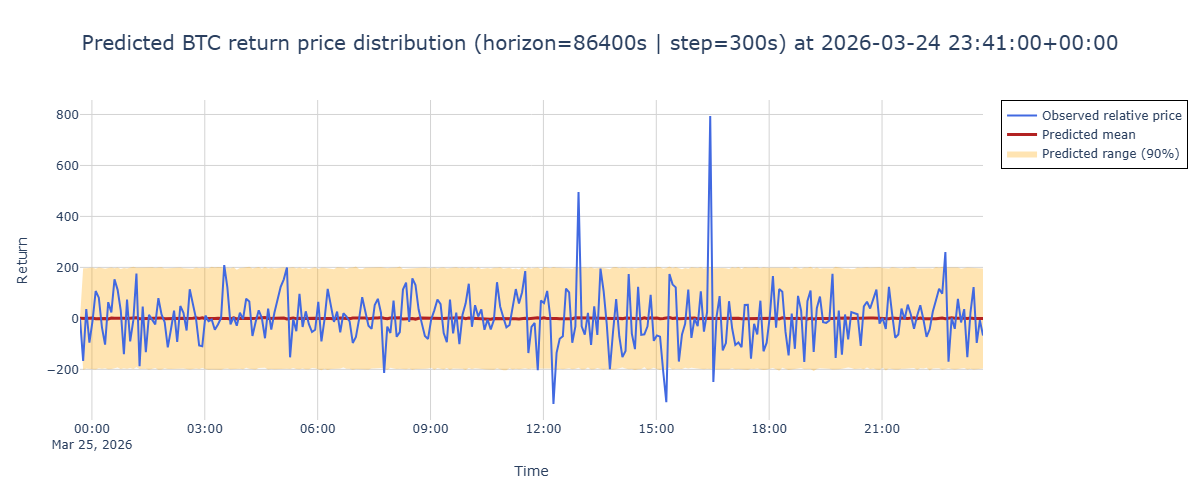

In [17]:
## Density forecast over returns (for the last asset and last prediction)
plot_quarantine(asset, predictions_evaluated[0], step=STEPS[0], prices=tracker_evaluator.tracker.prices, mode="direct")

Normalized CRPS score: 15.332844481509353


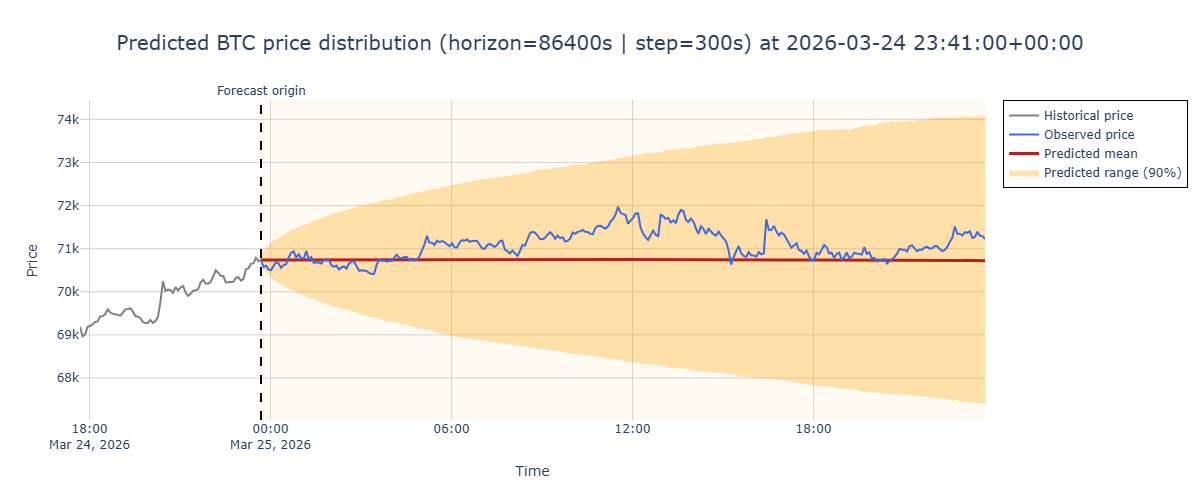

In [18]:
## Return forecast mapped into price space (for the last asset and last quarantine prediction)
print("Normalized CRPS score:", tracker_evaluator.scores[asset][-1][1])
plot_quarantine(asset, predictions_evaluated[0], step=STEPS[0], prices=tracker_evaluator.tracker.prices, mode="incremental", lookback_seconds=HORIZON/4)

# Tracker Comparison with all your custom trackers and live crunch trackers

Compare tracker results for the current experiment configuration.

- Lower CRPS indicates **better probabilistic forecasts**

To run and **compare multiple trackers**:
- **Assign unique class names to each custom Tracker** (e.g. `GaussianStepTracker`)
- Use **separate notebooks** or persist **results directory** in dedicated directories (e.g. on Google Drive)

In [19]:
from crunch_synth import load_all_results, merge_with_tracker_history, plot_tracker_comparison

# Load all custom tracker results for the current experiment configuration.
df_all = load_all_results(current_results_dir, horizon=HORIZON)
# Merge with live crunch trackers history
df_all = merge_with_tracker_history(df_all, df_trackers_history)

df_all

Directory: results\2026-03-20T01-01-00_to_2026-03-25T23-41-00\*h86400.json
[✔] Found 1 files:
   - LightGBMVolatilityTracker_h86400.json


,tracker,asset,horizon,score,time,mytracker
0,LightGBMVolatilityTracker,BTC,86400,16.266367,2026-03-20 01:01:00+00:00,True
1,LightGBMVolatilityTracker,BTC,86400,15.814014,2026-03-20 02:01:00+00:00,True
2,LightGBMVolatilityTracker,BTC,86400,16.234036,2026-03-20 03:02:00+00:00,True
3,LightGBMVolatilityTracker,BTC,86400,16.469070,2026-03-20 04:03:00+00:00,True
4,LightGBMVolatilityTracker,BTC,86400,16.250069,2026-03-20 05:03:00+00:00,True
...,...,...,...,...,...,...
26975,13641,BTC,86400,420.807204,2026-03-25 23:41:00+00:00,False
26976,13622,BTC,86400,14.462638,2026-03-25 23:41:00+00:00,False
26977,13762,BTC,86400,14.627772,2026-03-25 23:41:00+00:00,False
26978,13877,BTC,86400,14.575064,2026-03-25 23:41:00+00:00,False


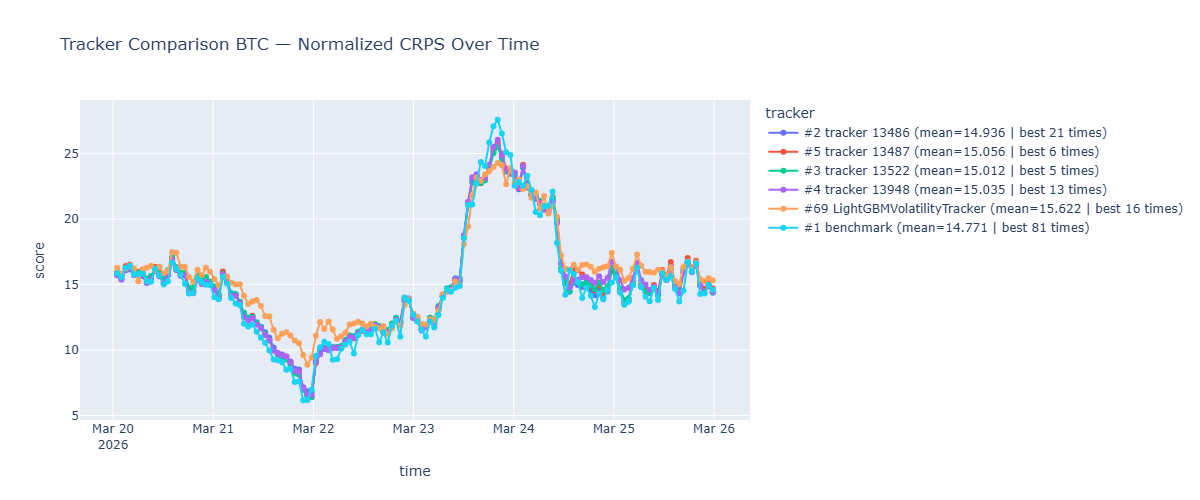

In [20]:
for asset in assets:
    # Tracker comparison all assets (A lower CRPS score reflects more accurate predictions)
    # Scores appear after quarantine: a score at time t evaluates a forecast issued at (t - horizon)
    plot_tracker_comparison(df_all, asset, top_n=5)

# Where to Experiment

You can improve the tracker by modifying:

### Feature engineering
`compute_feat()`

Ideas:
- rolling statistics
- volatility estimators
- momentum indicators
- regime detection

### Training data
`build_training_data()`

Ideas:
- different targets
- multi-horizon prediction
- alternative volatility measures

### Model
`train_model()`

Ideas:
- hyperparameter tuning
- different ML models
- ensemble models

### Forecast distribution
inside the tracker

Ideas:
- non-Gaussian distributions
- mixture models
- quantile forecasts

# Submit your Notebook

To submit your work, you must:
1. Download your Notebook from Colab
2. Optional: Download 'resources' directory (warm-start)
2. Upload it to the platform
3. Create a run to validate it

### >> https://hub.crunchdao.com/competitions/synth/submit/notebook

![Download and Submit Notebook](https://raw.githubusercontent.com/crunchdao/competitions/refs/heads/master/documentation/animations/download-and-submit-notebook.gif)